# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE

current_dir = os.getcwd()
dir_files = os.listdir()

print("Current Directory:", current_dir)
print("Directory Files:", dir_files)

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

def get_census_data(my_key):
    url = f'https://api.census.gov/data/2020/dec/dp?get=NAME,DP1_0001C,DP1_0077C,DP1_0078C,DP1_0079C,DP1_0080C,DP1_0081C,DP1_0082C,DP1_0083C,DP1_0093C,DP1_0084C&for=county:*&in=state:*&key={my_key}'
    response = requests.get(url)
    data = response.json()
    header, rows = data[0], data[1:]
    df = pd.DataFrame(rows, columns=header)

    cols_to_convert = [c for c in df.columns if c != "NAME"]
    df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

    df[['County', 'State']] = df['NAME'].str.split(',', expand=True)

    return df[["County","State","DP1_0001C","DP1_0077C","DP1_0078C","DP1_0079C","DP1_0080C","DP1_0081C","DP1_0082C","DP1_0083C","DP1_0093C", "DP1_0084C","county","state"]]

# API key is in a dotenv file
census_key = os.getenv("CENSUS_KEY")

census_df = get_census_data(census_key)

census_df.head(10)

Current Directory: /Users/erinpatterson/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
Directory Files: ['.env', 'hw_3.ipynb']


,County,State,DP1_0001C,DP1_0077C,DP1_0078C,DP1_0079C,DP1_0080C,DP1_0081C,DP1_0082C,DP1_0083C,DP1_0093C,DP1_0084C,county,state
0,Autauga County,Alabama,58805,55648,42160,11445,217,881,35,910,2117,3157,1,1
1,Baldwin County,Alabama,231767,216743,189399,18217,1582,2067,143,5335,12686,15024,3,1
2,Barbour County,Alabama,25223,24523,11317,11933,116,117,1,1039,1510,700,5,1
3,Bibb County,Alabama,22293,21534,16555,4413,60,32,9,465,740,759,7,1
4,Blount County,Alabama,59134,55478,50663,845,337,178,24,3431,5771,3656,9,1
5,Bullock County,Alabama,10357,10109,2320,7396,72,9,10,302,503,248,11,1
6,Butler County,Alabama,19051,18464,9752,8430,29,143,5,105,260,587,13,1
7,Calhoun County,Alabama,116441,110412,80586,25559,487,1190,119,2471,5010,6029,15,1
8,Chambers County,Alabama,34772,33562,18850,13512,106,401,13,680,1237,1210,17,1
9,Cherokee County,Alabama,24971,24051,22707,987,109,56,1,191,400,920,19,1


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- The United States Census Bureau's Demographic Profile API

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE

demographic_info = census_df.info()

demographic_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   County     3221 non-null   object
 1   State      3221 non-null   object
 2   DP1_0001C  3221 non-null   int64 
 3   DP1_0077C  3221 non-null   int64 
 4   DP1_0078C  3221 non-null   int64 
 5   DP1_0079C  3221 non-null   int64 
 6   DP1_0080C  3221 non-null   int64 
 7   DP1_0081C  3221 non-null   int64 
 8   DP1_0082C  3221 non-null   int64 
 9   DP1_0083C  3221 non-null   int64 
 10  DP1_0093C  3221 non-null   int64 
 11  DP1_0084C  3221 non-null   int64 
 12  county     3221 non-null   int64 
 13  state      3221 non-null   int64 
dtypes: int64(12), object(2)
memory usage: 352.4+ KB


In [3]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE

census_df = census_df.rename(columns={"DP1_0001C": "Total Population", "DP1_0077C": "One Race (OR)", "DP1_0078C": "White OR", "DP1_0079C": "Black or African American OR", "DP1_0080C": "American Indian and Alaska Native OR", "DP1_0081C": "Asian OR", "DP1_0082C": "Native Hawaiian/Pacific Islander OR", "DP1_0083C": "Other Race OR", "DP1_0093C": "Hispanic or Latino OR", "DP1_0084C": "Two or More Races",})
census_df.head(10)

,County,State,Total Population,One Race (OR),White OR,Black or African American OR,American Indian and Alaska Native OR,Asian OR,Native Hawaiian/Pacific Islander OR,Other Race OR,Hispanic or Latino OR,Two or More Races,county,state
0,Autauga County,Alabama,58805,55648,42160,11445,217,881,35,910,2117,3157,1,1
1,Baldwin County,Alabama,231767,216743,189399,18217,1582,2067,143,5335,12686,15024,3,1
2,Barbour County,Alabama,25223,24523,11317,11933,116,117,1,1039,1510,700,5,1
3,Bibb County,Alabama,22293,21534,16555,4413,60,32,9,465,740,759,7,1
4,Blount County,Alabama,59134,55478,50663,845,337,178,24,3431,5771,3656,9,1
5,Bullock County,Alabama,10357,10109,2320,7396,72,9,10,302,503,248,11,1
6,Butler County,Alabama,19051,18464,9752,8430,29,143,5,105,260,587,13,1
7,Calhoun County,Alabama,116441,110412,80586,25559,487,1190,119,2471,5010,6029,15,1
8,Chambers County,Alabama,34772,33562,18850,13512,106,401,13,680,1237,1210,17,1
9,Cherokee County,Alabama,24971,24051,22707,987,109,56,1,191,400,920,19,1


In [4]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE

census_df = census_df.drop(columns={'state', 'county'})
census_df.head(10)

,County,State,Total Population,One Race (OR),White OR,Black or African American OR,American Indian and Alaska Native OR,Asian OR,Native Hawaiian/Pacific Islander OR,Other Race OR,Hispanic or Latino OR,Two or More Races
0,Autauga County,Alabama,58805,55648,42160,11445,217,881,35,910,2117,3157
1,Baldwin County,Alabama,231767,216743,189399,18217,1582,2067,143,5335,12686,15024
2,Barbour County,Alabama,25223,24523,11317,11933,116,117,1,1039,1510,700
3,Bibb County,Alabama,22293,21534,16555,4413,60,32,9,465,740,759
4,Blount County,Alabama,59134,55478,50663,845,337,178,24,3431,5771,3656
5,Bullock County,Alabama,10357,10109,2320,7396,72,9,10,302,503,248
6,Butler County,Alabama,19051,18464,9752,8430,29,143,5,105,260,587
7,Calhoun County,Alabama,116441,110412,80586,25559,487,1190,119,2471,5010,6029
8,Chambers County,Alabama,34772,33562,18850,13512,106,401,13,680,1237,1210
9,Cherokee County,Alabama,24971,24051,22707,987,109,56,1,191,400,920


In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

census_df = census_df.dropna()
census_df.head(10)

,County,State,Total Population,One Race (OR),White OR,Black or African American OR,American Indian and Alaska Native OR,Asian OR,Native Hawaiian/Pacific Islander OR,Other Race OR,Hispanic or Latino OR,Two or More Races
0,Autauga County,Alabama,58805,55648,42160,11445,217,881,35,910,2117,3157
1,Baldwin County,Alabama,231767,216743,189399,18217,1582,2067,143,5335,12686,15024
2,Barbour County,Alabama,25223,24523,11317,11933,116,117,1,1039,1510,700
3,Bibb County,Alabama,22293,21534,16555,4413,60,32,9,465,740,759
4,Blount County,Alabama,59134,55478,50663,845,337,178,24,3431,5771,3656
5,Bullock County,Alabama,10357,10109,2320,7396,72,9,10,302,503,248
6,Butler County,Alabama,19051,18464,9752,8430,29,143,5,105,260,587
7,Calhoun County,Alabama,116441,110412,80586,25559,487,1190,119,2471,5010,6029
8,Chambers County,Alabama,34772,33562,18850,13512,106,401,13,680,1237,1210
9,Cherokee County,Alabama,24971,24051,22707,987,109,56,1,191,400,920


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE

def get_gender_data(my_key):
    url = f'https://api.census.gov/data/2020/dec/dp?get=NAME,DP1_0001C,DP1_0025C,DP1_0049C&for=county:*&in=state:*&key={my_key}'
    response = requests.get(url)
    data = response.json()
    header, rows = data[0], data[1:]
    df = pd.DataFrame(rows, columns=header)

    cols_to_convert = [c for c in df.columns if c != "NAME"]
    df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

    df[['County', 'State']] = df['NAME'].str.split(',', expand=True)

    return df[["County", "State","DP1_0001C","DP1_0025C","DP1_0049C","state"]]

census_key = os.getenv("CENSUS_KEY")

gender_df = get_gender_data(census_key)

gender_df = gender_df.rename(columns={"DP1_0001C": "Total Population", "DP1_0025C": "Male Population", "DP1_0049C": "Female Population"}).drop(columns={"state"})
gender_info = gender_df.info()

gender_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   County             3221 non-null   object
 1   State              3221 non-null   object
 2   Total Population   3221 non-null   int64 
 3   Male Population    3221 non-null   int64 
 4   Female Population  3221 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 125.9+ KB


,County,State,Total Population,Male Population,Female Population
0,Autauga County,Alabama,58805,28390,30415
1,Baldwin County,Alabama,231767,112627,119140
2,Barbour County,Alabama,25223,13167,12056
3,Bibb County,Alabama,22293,11798,10495
4,Blount County,Alabama,59134,29197,29937
5,Bullock County,Alabama,10357,5628,4729
6,Butler County,Alabama,19051,8971,10080
7,Calhoun County,Alabama,116441,55787,60654
8,Chambers County,Alabama,34772,16902,17870
9,Cherokee County,Alabama,24971,12327,12644


In [7]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE

# Merging on County name using inner
df_merged_census = pd.merge(
    gender_df[["County", "State", "Total Population", "Male Population", "Female Population"]],
    census_df,
    on=["County", "State"],
    how="inner",
)

df_merged_census = df_merged_census.drop(columns={"Total Population_y"})
df_merged_census = df_merged_census.rename(columns={"Total Population_x": "Total Population"})

merged_info = df_merged_census.info()

print("Merged Gender and Demographic Census by State:", df_merged_census.shape)
df_merged_census.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   County                                3221 non-null   object
 1   State                                 3221 non-null   object
 2   Total Population                      3221 non-null   int64 
 3   Male Population                       3221 non-null   int64 
 4   Female Population                     3221 non-null   int64 
 5   One Race (OR)                         3221 non-null   int64 
 6   White OR                              3221 non-null   int64 
 7   Black or African American OR          3221 non-null   int64 
 8   American Indian and Alaska Native OR  3221 non-null   int64 
 9   Asian OR                              3221 non-null   int64 
 10  Native Hawaiian/Pacific Islander OR   3221 non-null   int64 
 11  Other Race OR                 

,County,State,Total Population,Male Population,Female Population,One Race (OR),White OR,Black or African American OR,American Indian and Alaska Native OR,Asian OR,Native Hawaiian/Pacific Islander OR,Other Race OR,Hispanic or Latino OR,Two or More Races
0,Autauga County,Alabama,58805,28390,30415,55648,42160,11445,217,881,35,910,2117,3157
1,Baldwin County,Alabama,231767,112627,119140,216743,189399,18217,1582,2067,143,5335,12686,15024
2,Barbour County,Alabama,25223,13167,12056,24523,11317,11933,116,117,1,1039,1510,700
3,Bibb County,Alabama,22293,11798,10495,21534,16555,4413,60,32,9,465,740,759
4,Blount County,Alabama,59134,29197,29937,55478,50663,845,337,178,24,3431,5771,3656
5,Bullock County,Alabama,10357,5628,4729,10109,2320,7396,72,9,10,302,503,248
6,Butler County,Alabama,19051,8971,10080,18464,9752,8430,29,143,5,105,260,587
7,Calhoun County,Alabama,116441,55787,60654,110412,80586,25559,487,1190,119,2471,5010,6029
8,Chambers County,Alabama,34772,16902,17870,33562,18850,13512,106,401,13,680,1237,1210
9,Cherokee County,Alabama,24971,12327,12644,24051,22707,987,109,56,1,191,400,920


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- Merged on State and County name and was able to keep all rows

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE

gender_stats = df_merged_census.groupby("State")[["Male Population", "Female Population"]].agg(["mean", "median", "min", "max"])
hapa_stats = df_merged_census.groupby("State")["Two or More Races"].agg(["mean", "median", "min", "max"]).sort_values(by='mean', ascending=False)

hapa_stats.head(10)

,mean,median,min,max
State,,,,
California,99314.396552,25019.5,119,1488068
Hawaii,73625.800000,40168.0,22,248686
Arizona,66453.733333,17011.0,1564,600675
District of Columbia,56077.000000,56077.0,56077,56077
Florida,53016.000000,10951.0,329,1131581
Massachusetts,43490.500000,45841.0,1387,134739
New Jersey,43023.523810,37340.0,4677,104485
Connecticut,41613.000000,18609.5,9221,102835
New York,28507.467742,5177.0,242,243364


- *Extra Credit: Write your economic or policy related interpretation here*

States or Counties with higher numbers of multiracial individuals could be more liberal leaning states because it implies more immigration and more interracial marriage/relationships. Maybe this could also imply a higher female population.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

/var/folders/_1/86vrhcd148jb1w47rcyvky8c0000gn/T/ipykernel_27346/1499375783.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(state_avg_multiracial.index, rotation=90, fontsize=10)


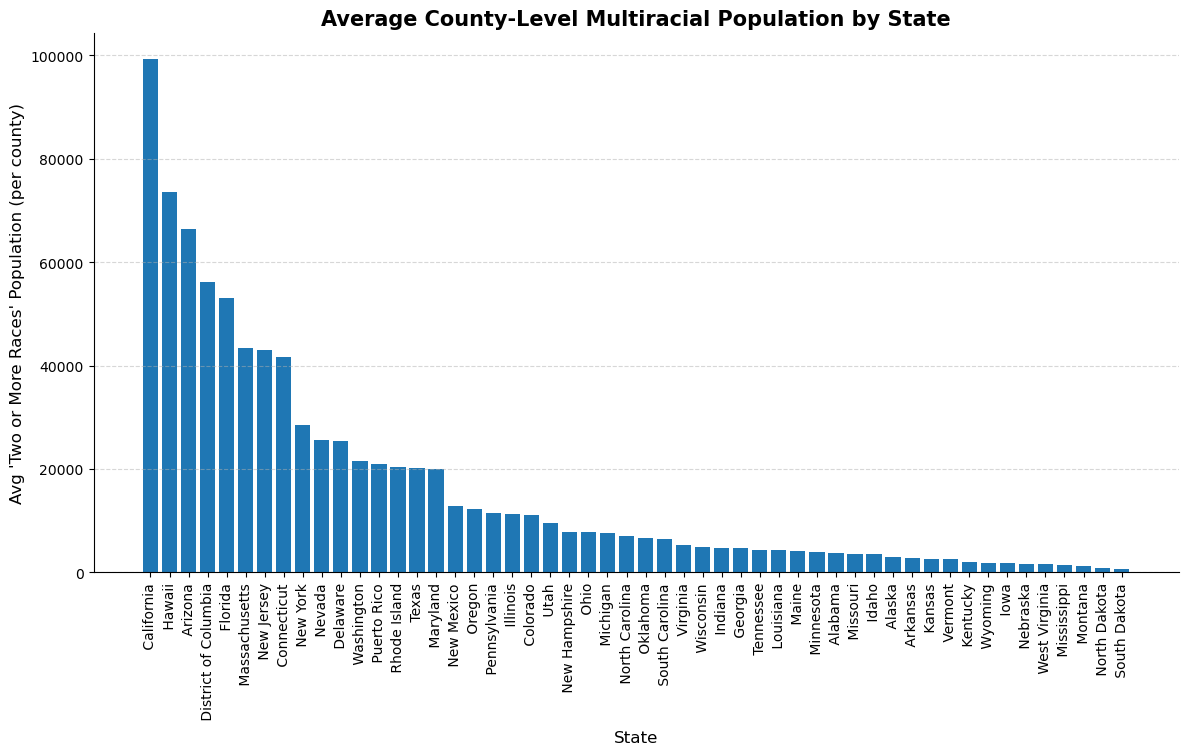

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE

state_avg_multiracial = df_merged_census.groupby("State")["Two or More Races"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(state_avg_multiracial.index, state_avg_multiracial.values)

ax.set_title("Average County-Level Multiracial Population by State", fontsize=15, fontweight="bold")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Avg 'Two or More Races' Population (per county)", fontsize=12)
ax.set_xticklabels(state_avg_multiracial.index, rotation=90, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

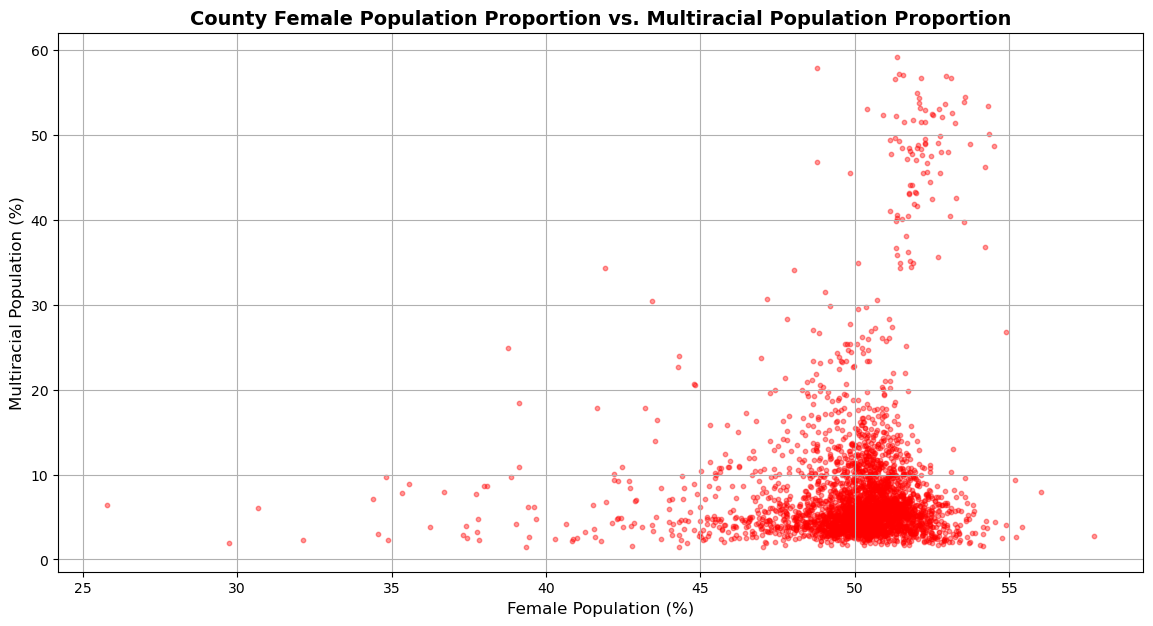

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE

df_merged_census["Pct Multiracial"] = df_merged_census["Two or More Races"] / df_merged_census["Total Population"] * 100
df_merged_census["Pct Female"] = df_merged_census["Female Population"] / df_merged_census["Total Population"] * 100

df_merged_census.head(10)

df_plot = df_merged_census

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df_merged_census["Pct Female"], df_merged_census["Pct Multiracial"],
           color="red", alpha=0.4, s=10)

plt.xlabel("Female Population (%)", fontsize=12)
plt.ylabel("Multiracial Population (%)", fontsize=12)
plt.title("County Female Population Proportion vs. Multiracial Population Proportion", fontsize=14, fontweight="bold")
plt.grid(True)
plt.show()

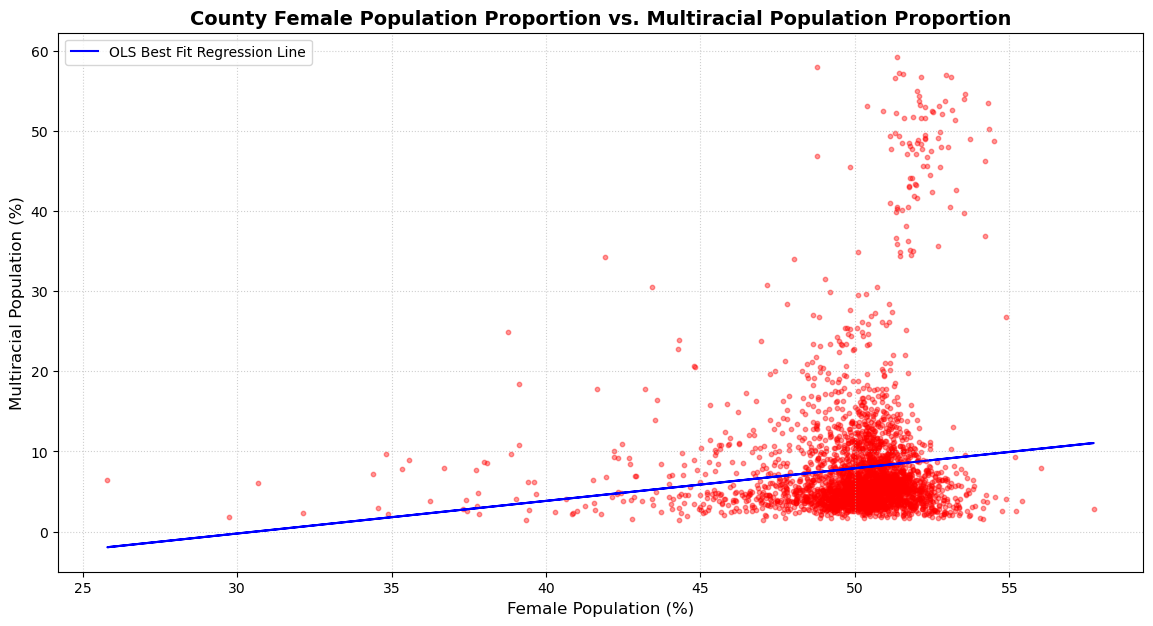

In [11]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE

import statsmodels.api as sm

X_real = df_merged_census['Pct Female']
y_real = df_merged_census['Pct Multiracial']
X_real_const = sm.add_constant(X_real)

model_real = sm.OLS(y_real, X_real_const).fit()
model_real

#Plot Regression Line
fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(df_merged_census["Pct Female"], df_merged_census["Pct Multiracial"],
           color="red", alpha=0.4, s=10)

intercept_real, slope_real = model_real.params.iloc[0], model_real.params.iloc[1]

# 2. Match the regression line calculation to the X values (ladder_score)
plt.plot(df_merged_census['Pct Female'], intercept_real + slope_real * df_merged_census['Pct Female'], color='blue', label='OLS Best Fit Regression Line')

# 3. Label the axes correctly
plt.xlabel("Female Population (%)", fontsize=12)
plt.ylabel("Multiracial Population (%)", fontsize=12)
plt.title("County Female Population Proportion vs. Multiracial Population Proportion", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

There could be evidence of a weak relationship between multiracial population numbers and female population numbers.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.